# **Meteorite Landings Analysis**

In [1]:
set.seed(2026)
library(tidyverse)
library(rsample)
library(broom)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## **Summary**
This project delves into the NASA Meteorite Landings dataset to gain insight into how meteorite mass varies over time, location, and meteorite classification. Meteorite mass is a fundamental characteristic of a meteorite, and understanding what influences its variation can shed valuable light on the nature of meteorite populations. Using R, the project applies data cleaning, exploratory visualization, and linear regression modelling to examine whether temporal trends, geographic patterns, and meteorite class interactions can explain the differences in meteorite mass. 

### NASA Meteorite Landings Dataset
The dataset was acquired from NASA’s publicly available meteorite database and contains records of meteorite landings and discoveries around the world. The variables used in this analysis include:
- `mass`: the physical mass of the meteorite sample (grams)
- `year`: the year that the meteorite was observed
- `GeoLocation`: coordinates (latitude, longitude) of the landing or discovery location
- - `relong`: longitude of location
  - `relat`: latitude of location
- `reclass`: class of a meteorite 
- `fall`: whether the meteorite was *found* or *fell* 

After conducting preprocessing steps to the dataset, the five most common meteorite classes for modelling. A Gaussian linear regression model is fitted to predict the log-transformed meteorite mass using the following formula: 

$$\log_{10}(\text{mass}) \sim \text{year} \times \text{recclass} + \text{reclat} + \text{reclong} + \text{fall}$$

A log transformation is applied to the mass variable to address skewness in the raw distribution, effectively capturing the underlying linear relationships. Interaction between year and meteorite class was included in the analysis to allow the model to assess whether mass trends over time vary across meteorite types. 

### Outputs
Two visualizations are produced from the analysis:  
1. **Regression of meteorite class over time**: visualizes how predicted meteorite mass changed across years for each of the five selected common meteorite classes
2. **Predicted vs. actual log-mass values**: portrays a plot used to evaluate the predictive performance and fit of the regression model

### Reproducibility
The analysis is produced entirely in R and is designed to be fully reproducible by running RStudio locally with renv, or through Docker using the provided Dockerfile.


## **Introduction**
A meteorite is defined as a meteoroid that survives a fall through the atmosphere and hits land. Meteoroids are stagnant rocks in space, with their size ranging from a speck of dust to the size of an asteroid. Most meteoroids are chunks or debris of other larger bodies that have been destructed; these can be rocky, metallic, or a combination of both rock and metal (NASA, 2024). Meteors are meteoroids that enter the atmosphere burning at a high speed, often seen as “shooting stars” (NASA, 2024). Meteorites that land on Earth are among the oldest and most diverse materials from the formation of our solar system. Studying meteorite landings allows scientists to discover and reconstruct key aspects of our planetary history, including the age and composition of planets, and the extent to which materials were changed by previous impacts. 

Despite their historical and scientific relevance, meteorite landings are affected by a range of geographic aspects. Factors such as where a meteorite lands, when it is discovered, and how it is classified play a crucial role in determining how accurately they represent the true distribution of meteorites. In particular, meteorite mass is a fundamental characteristic that can be used to describe and compare meteorite samples across different classes and discovery conditions; it can be used to observe how it fluctuates against time, location, and meteorite class. This project leverages NASA’s Meteorite Landings dataset to explore these patterns. By building a linear regression model to predict the logarithm of meteorite mass based on year, class, location, and whether the meteorite was found or observed falling, this project aims to contribute to a deeper understanding of both the physical nature of meteorites and discovery patterns that shape the history of meteorites. 


## **Methods**

### Data Loading

The analysis uses the NASA Meteorite Landings dataset, which contains recorded meteorite observations worldwide, including mass (grams), year of landing, geographic coordinates (latitude and longitude), meteorite classification, and fall status (Fell vs Found).

The dataset was loaded from the original CSV source and imported into R using `read.csv()`.

In [13]:
# Read in data
file_url <- "https://data.nasa.gov/docs/legacy/meteorite_landings/Meteorite_Landings.csv"
dest_file <- "data/raw/meteorite_landings.csv"
download.file(file_url, dest_file, method = "auto")

meteors <- read.csv("../data/raw/meteorite_landings.csv")
head(meteors)

Warning message in download.file(file_url, dest_file, method = "auto"):
“URL https://data.nasa.gov/docs/legacy/meteorite_landings/Meteorite_Landings.csv: cannot open destfile 'data/raw/meteorite_landings.csv', reason 'No such file or directory'”
Warning message in download.file(file_url, dest_file, method = "auto"):
“download had nonzero exit status”


,name,id,nametype,recclass,mass..g.,fall,year,reclat,reclong,GeoLocation
,<chr>,<int>,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<chr>
1,Aachen,1,Valid,L5,21,Fell,1880,50.77500,6.08333,"(50.775, 6.08333)"
2,Aarhus,2,Valid,H6,720,Fell,1951,56.18333,10.23333,"(56.18333, 10.23333)"
3,Abee,6,Valid,EH4,107000,Fell,1952,54.21667,-113.00000,"(54.21667, -113.0)"
4,Acapulco,10,Valid,Acapulcoite,1914,Fell,1976,16.88333,-99.90000,"(16.88333, -99.9)"
5,Achiras,370,Valid,L6,780,Fell,1902,-33.16667,-64.95000,"(-33.16667, -64.95)"
6,Adhi Kot,379,Valid,EH4,4239,Fell,1919,32.10000,71.80000,"(32.1, 71.8)"


### Data Wrangling and Cleaning

The dataset required preprocessing before modeling:

1. Observations with missing values in the following variables were removed:  
   * `mass..g.`  
   * `year`  
   * `reclat`  
   * `reclong`  
   * `fall`  
   * `recclass`  
2. Variable types were standardized:  
   * `mass`, `year`, `reclat`, and `reclong` were converted to numeric.  
   * `fall` and `recclass` were converted to categorical (factor) variables.  
3. Observations with non-positive mass values were removed.  
4. Because meteorite mass is highly right-skewed, a base-10 logarithmic transformation was applied:  
   $$  
   log_{mass} = \\log_{10} \text{ mass}  
   $$
   This transformation stabilizes variance and makes linear regression more appropriate.  
5. To avoid sparse categories and improve interpretability, only the five most frequent meteorite classifications were retained in the final dataset.

No structural changes were made to the observational content of the dataset. The preprocessing primarily standardized data types, removed incomplete records, and applied a log transformation.

In [14]:
# Clean data
meteors_clean <- meteors %>%
  drop_na(mass..g., year, reclat, reclong, fall, recclass) %>%
  mutate(
    mass = as.numeric(mass..g.),
    year = as.numeric(year),
    reclat = as.numeric(reclat),
    reclong = as.numeric(reclong)
  ) %>%
  drop_na(mass, year, reclat, reclong) %>%
  filter(mass > 0) %>%
  mutate(
    log_mass = log10(mass),
    fall = as.factor(fall),
    recclass = as.factor(recclass)
  )

top_classes <- meteors_clean %>%
  count(recclass, sort = TRUE) %>%
  slice_head(n = 5) %>%
  pull(recclass)

meteors_clean <- meteors_clean %>%
  filter(recclass %in% top_classes)

### Train-Test Split

The cleaned dataset was randomly split into:

* 80% training data  
* 20% testing data

The training set was used to fit the regression model, and the testing set was used to evaluate predictive performance.

In [15]:
# Split data into training/testing
split_obj <- initial_split(meteors_clean, prop = 0.8)
train_data <- training(split_obj)
test_data  <- testing(split_obj)
head(test_data)

,name,id,nametype,recclass,mass..g.,fall,year,reclat,reclong,GeoLocation,mass,log_mass
,<chr>,<int>,<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
1,Aachen,1,Valid,L5,21,Fell,1880,50.77500,6.08333,"(50.775, 6.08333)",21,1.322219
2,Agen,392,Valid,H5,30000,Fell,1814,44.21667,0.61667,"(44.21667, 0.61667)",30000,4.477121
3,Akbarpur,427,Valid,H4,1800,Fell,1838,29.71667,77.95000,"(29.71667, 77.95)",1800,3.255273
4,Alessandria,463,Valid,H5,908,Fell,1860,44.88333,8.75000,"(44.88333, 8.75)",908,2.958086
5,Allegan,2276,Valid,H5,32000,Fell,1899,42.53333,-85.88333,"(42.53333, -85.88333)",32000,4.505150
6,Andura,2298,Valid,H6,17900,Fell,1939,20.88333,76.86667,"(20.88333, 76.86667)",17900,4.252853


### Regression Model

A linear regression model (Gaussian family) was fitted using:

$$
\log(\text{mass}) \sim \text{year} * \text{recclass} + \text{reclat} + \text{reclong} + \text{fall}
$$


This model includes:

* Main effects of year, meteorite classification, latitude, longitude, and fall status.  
* Interaction terms between year and meteorite classification.

The interaction allows the relationship between time and meteorite mass to vary across classification types.

In [17]:
# Linear Regression model
model <- glm(
  log_mass ~ year * recclass + reclat + reclong + fall,
  data = train_data,
  family = gaussian()
)
tidy_model <- head(tidy(model))
tidy_model

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),25.13672726,1.9489119349,12.897826,6.577222e-38
year,-0.01144832,0.0009841003,-11.633285,3.524730e-31
recclassH5,-4.65150326,2.3467293151,-1.982122,4.747940e-02
recclassH6,-7.51498498,2.4446893274,-3.074004,2.114933e-03
recclassL5,2.98366300,2.7366909222,1.090245,2.756186e-01
recclassL6,-10.14690980,2.1017551762,-4.827827,1.390593e-06


### Model Evaluation

Predicted log₁₀(mass) values were generated for the testing dataset and compared against actual observed values.



In [20]:
# Predictions

year_seq <- seq(min(meteors_clean$year), max(meteors_clean$year), length.out = 100)

predictions <- predict(model, newdata = test_data)
prediction_grid <- expand.grid(
  year = year_seq,
  reclat = mean(meteors_clean$reclat),
  reclong = mean(meteors_clean$reclong),
  fall = levels(meteors_clean$fall)[1],   # fix one category
  recclass = top_classes
)

prediction_grid$pred_log_mass <- predict(model, newdata = prediction_grid)

year,reclat,reclong,fall,recclass,pred_log_mass
<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>
860.0000,-43.16525,65.40405,Fell,L6,9.191633
871.6465,-43.16525,65.40405,Fell,L6,9.118896
883.2929,-43.16525,65.40405,Fell,L6,9.046159
894.9394,-43.16525,65.40405,Fell,L6,8.973421
906.5859,-43.16525,65.40405,Fell,L6,8.900684
918.2323,-43.16525,65.40405,Fell,L6,8.827946
929.8788,-43.16525,65.40405,Fell,L6,8.755209
941.5253,-43.16525,65.40405,Fell,L6,8.682472
953.1717,-43.16525,65.40405,Fell,L6,8.609734


### Exploratory Visualization

To visualize temporal patterns across meteorite classes, a scatterplot of log₁₀(mass) versus year was created for the five most frequent classes. Model-based regression lines were overlaid for each class.

**Figure 1\. Regression Lines by Meteorite Class.**  
Scatterplot of log₁₀(mass) versus year with class-specific regression lines estimated from the fitted linear model.

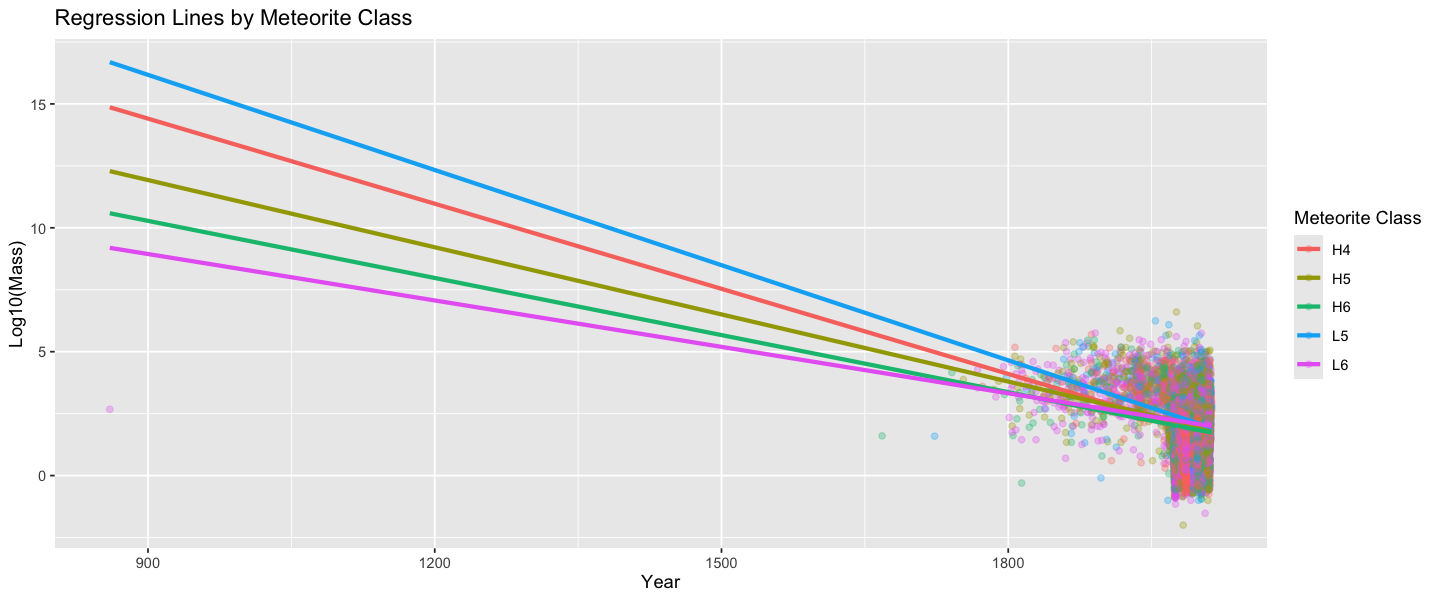

In [23]:
# Plot
options(repr.plot.width = 12, repr.plot.height = 5)

plot_classes <- ggplot(meteors_clean, aes(x = year, y = log_mass, color = recclass)) +
  geom_point(alpha = 0.3) +
  geom_line(
    data = prediction_grid,
    aes(x = year, y = pred_log_mass, color = recclass),
    linewidth = 1.2
  ) +
  labs(
    title = "Regression Lines by Meteorite Class",
    x = "Year",
    y = "Log10(Mass)",
    color = "Meteorite Class"
  )

plot_classes

**Interpretation of Figure 1**

Figure 1 shows a downward trend in predicted log₁₀(mass) over time across all major meteorite classes.

Key observations:

* All classes exhibit decreasing predicted mass over time.  
* The slopes differ slightly across classes, reflecting the interaction between year and meteorite classification.  
* Recent years show greater density of smaller-mass meteorites.

This pattern is consistent with improvements in detection technology over time, allowing smaller meteorites to be recorded in more recent periods.

**Figure 2\. Predicted vs Actual Log₁₀(Mass).**  
Scatterplot comparing predicted values from the regression model to actual observed log₁₀(mass) values. The red 45-degree line represents perfect prediction.

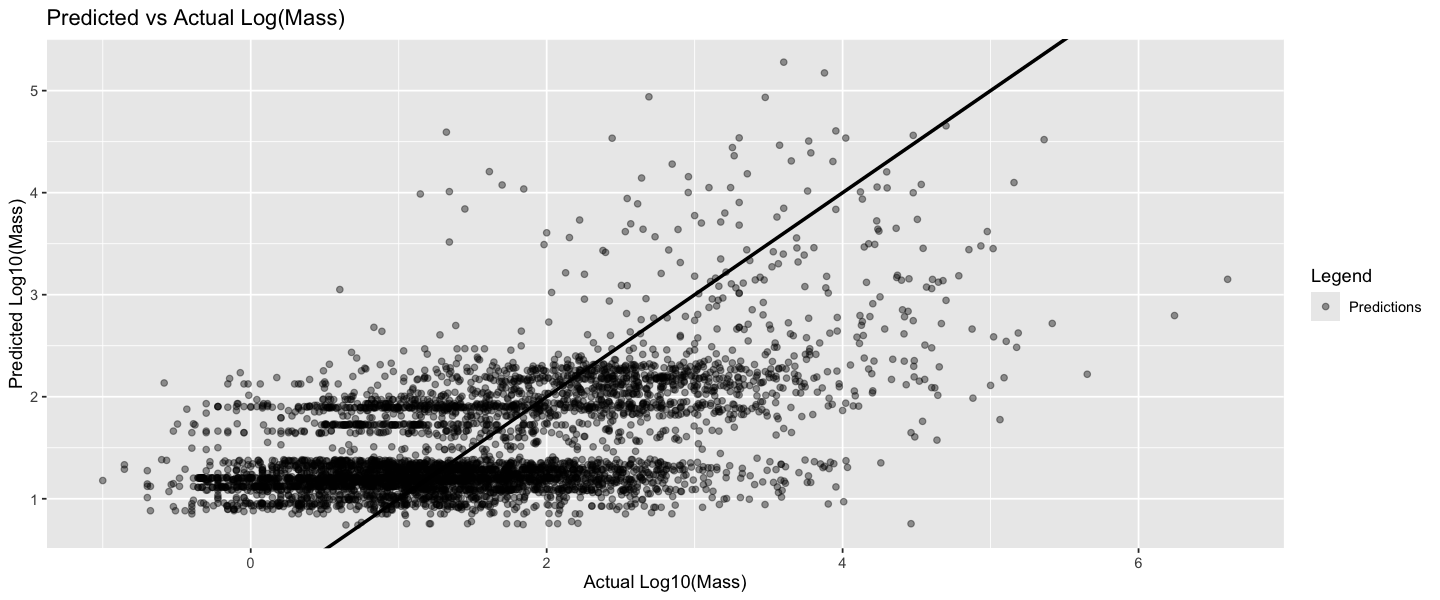

In [36]:
options(repr.plot.width = 12, repr.plot.height = 5)

plot_pred_vs_act <- ggplot(test_data, aes(x = log_mass, y = predictions)) +
  geom_point(aes(color = "Predictions"), alpha = 0.4) +
  geom_abline(intercept = 0, slope = 1, linewidth = 1) +
  scale_color_manual(
    name = "Legend",
    values = c("Predictions" = "black", "Perfect Fit" = "red")
  ) +
  labs(
    title = "Predicted vs Actual Log(Mass)",
    x = "Actual Log10(Mass)",
    y = "Predicted Log10(Mass)"
  )

plot_pred_vs_act


**Predictive Performance (Figure 2\)**

The predicted versus actual plot reveals:

* The model captures overall trends but does not perfectly align with the 45-degree reference line.  
* Predictions tend to be more concentrated than actual values, particularly for extreme masses.  
* Larger meteorites exhibit greater prediction variability.

Overall, the regression model explains systematic variation in meteorite mass but does not fully capture extreme outliers.

## **Results**

The regression results indicate the presence of **temporal and class effects**:

* A statistically significant negative association between year and log₁₀(mass), suggesting that more recent meteorite observations tend to have lower recorded mass.  
* Significant interaction effects between year and several meteorite classes, indicating that the temporal trend in mass differs by classification.  
* Latitude and longitude were statistically significant predictors, suggesting spatial variation in recorded meteorite mass.  
* Fall status (Found vs Fell) was associated with systematic differences in log-mass.

The analysis demonstrates that log-transformed meteorite mass is associated with temporal, geographic, and compositional characteristics. Temporal effects vary across meteorite classes, and geographic location contributes additional explanatory power. While the model captures general trends, predictive accuracy remains moderate, particularly for extreme values.


## **Discussion**

The analysis examined how characteristics of meteorite landings relate to meteorite mass. Using the NASA Meteorite Landings dataset, we built a linear regression model predicting the logarithm of meteorite mass (log_mass) based on the year of discovery, meteorite class (recclass), geographic coordinates (latitude, and longitude), and whether the meteorite was observed fallling or found later (fall). Interaction terms between year and meteorite class were also included to capture class-specific temporal trends. The dataset used in this analysis comes from the NASA Meteorite Landings database, which compiles meteorite discovery records including mass, location, classification, and year of fall or discovery.

### Summary of Findings

Several meaningful patterns emerged from the regression model.

First, year showed a statistically significant negative relationship with meteorite mass. The coefficient for year was negative, suggesting that more recently discovered meteorites tend to have smaller masses compared to earlier discoveries. One plausible explanation is that improvements in detection technology and scientific monitoring have made it easier to detect smaller meteorites that would previously have gone unnoticed. As meteorite observation networks nad scientific cataloguing efforts have expanded over time, the number of recorded meteorites has increased signficantly.

Second, meteorite class plays an important role in determining mass. Several meteorite classes, including H5 and H6, showed statistically significant differences in predicted mass relative to the reference class. Meteorite classifications reflect differences in mineral composition, metal content, and thermal history. These physical differences influence how meteorites form, fragment, and survive atmospheric entry. For example, different chondrite groups originate from different parent bodies i the asteroid belt and may therefore exhibit variation in density and structural composition.

Third, the interaction terms between year and meteorite class were significant for multiple classes. This indicates that the relationship between discovery year and meteorite mass varies across meteorite types. Some meteorite classes appear to exhibit stronger temporal trends in mass than others. Planetary science research suggests that meteorites originate from different asteroids and parent bodies, meaning that different classes can possess distinct compositional and structural characteristics. These differences may influence how meteorites fragment during atmospheric entry and how frquently they are recovered.

Fourth, geographic location also showed statistically signficant relationships with meteorite mass. Both latitude and longitude had statistically significant coefficients, although their magnitudes were relatively small. These geographic effects liekly reflect observational and recovery bias rather than true physical differences in meteorite mass distribution. Meteorites are easier to detect in sparsely vegetated or lightly populated environments such as deserts or polar regions, where fragments remain visible and well preserved. Meteorite recovery efforts in such regions have contirbuted substantially to meteorite collections and scientific research.

Finally, fall status ("Fell" vs "Found") was associated with systematic differences in meteorite mass. Meteorites classified as "Found" tended to have lower predicted mass values compared to meteorites that were directly observed falling. A likely explanation is that smaller meteorites often go unnoticed during atmospheric entry and are only discovered later through geological surveys or scientific expeditions.

### Were These Findings Expected?

Many of the observed patterns are consistent with expectations from meteoritics and observational science. The negative relationship between discovery year and mass aligns with historical developments in meteorite detection. Earlier meteorite records were typically limited to large and visually dramatic falls that were easily observed or caused noticeable damage. In contrast, modern monitoring networks, satellite tracking systems, and increased scientific interest have allowed researchers to catalogue many small meteorites.

Similarly, the importance of meteorite class was anticipated. Meteorite classifications reflect fundamental differences in mineral composition, iron content, and thermal history, which influence how meteorites fragment during atmospheric entry. Consequently, it is reasonable that certain classes are associated with systematically different mass distributions.

The geographic effects observed in the model were also somewhat expected. These relationships likely reflect detection and preservtion bias rather than actual geographic variation in meteorite mass. Certain environments preserve meteorites more effectively or make them easier to identify, which can influence the spatial distribution of recorded meteorite discoveries.

Overall, the model results align with both scientific expectations and known observational biases present in meteorite discovery trends

### Potential Impact of These Findings

Understanding patterns in meteorite mass and discovery characteristics can have several important implications.

First, these findings help improve our understanding of meteorite detection biases. Recognizing how factors such as location, observation method, and historical time period influence meteorite records allows researchers to better interpret meteorite datasets and avoid misleading conclusions about meteorite distributions.

Second, these results may support improvements in meteorite search strategies. If certain regions or environmental conditions are associated with higher detection rates of particular meteorite classes or sizes, scientific expeditions could prioritize thos environments when conducting meteorite recovery efforts. 

Third, the analysis contributes to broader planetary science research. Meteorites provide valuable information about the early solar system, asteroid formation, and planetary materials. Understanding patterns in meteorite characteristics helps scientists better interpret recovered samples and reconstruct the processes that shaped our solar system.

Finally, such models may contribute to risk assessment related to meteorite impacts. While most meteorites are small and harmless, analyzing long-term mass distribution and fall patterns improves our understanding of atmospheric entry processes and impact probabilities.

### Limitations of the Study

One limitation of this anlaysis is that the regression model assumes linear relationships between the predictors and the log-transformed meteorite mass. While this simplifies interpretation, meteorite mass distributions may involve nonlinear relationships or additional physical variables not captred in the dataset. Additionally, meteorite discovery records are strongly influenced by observational and recovery biases, meaning the dataset may not perfectly represent the true global distribution meteorites that reach Earth.

### Future Research Questions

This analysis also raises several interesting questions that could be explored in future research.

One potential direction would be to examine how detection bias affects meteorite records over time. Future models could incorporate changes in observational technologies, satellite monitoring systems, or meteorite tracking networks.

Another promising avenue would be to investigate regional meteorite discovery patterns. For example, deserts and polar regions have yielded large numbers of meteorite discoveries due to favorable preservation conditions. A spatial analysis incorporating environmental variables could provide deeper insights into these patterns.

Future research could also explore more flexible modeling approaches, such as nonlinear regression methods or machine learning models. While linear regression provides interpretable results, models such as random forests or gradient boosting could potentially capture more complex relationships between meteorite characteristics.

Additionally, incorporating additional meteorite properties, such as chemical composition, density, or atmospheric entry velocity, could improve predictions of meteorite mass and provide deeper insight into fragmentation processes.

## **References**
NASA. (n.d.). Meteorite landings. *NASA Open Data Portal*. https://data.nasa.gov/dataset/meteorite-landings

NASA. (2024). Meteor & meteorite facts. *NASA Science*. https://science.nasa.gov/solar-system/meteors-meteorites/facts/ 

Smithsonian Institution. (n.d.). Meteorite landing data. *Smithsonian Institution Repository*. https://repository.si.edu/handle/10088/20577

Lauretta, D. S., & McSween, H. Y. (Eds.). (2006). Meteorites and the early solar system II. *University of Arizona Press*. https://scispace.com/pdf/meteorites-and-the-early-solar-system-ii-4cwftrzhot.pdf

Natural History Museum. (n.d.). Types of meteorites. *Natural History Museum.* https://www.nhm.ac.uk/discover/types-of-meteorites.html
